## Importing the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from thefuzz import process, fuzz


# Data preparation

## 1-Data Inspection

#### Load data

In [3]:
df_hit=pd.read_csv('homeintunisia_appartement_vente.csv')

In [4]:
df_mub=pd.read_csv('mubawab_apartement_vente.csv')

In [5]:
df_star=pd.read_csv('properstar_appartement_acheter.csv')

In [6]:
df_remax=pd.read_csv('remax_apartement_vente.csv')

In [7]:
euro_to_dinar=3.38

#### Inspect data

In [8]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Sous-sol 6 m²,Terrain 572 m²,Terrains 2032 m²,Terrains 1000 m²,Terrains 1291 m²,Terrains 1293 m²,Terrains 1667 m²,Terrains 8940 m²,Terrains 5160 m²,Appartement 109 m²
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,Superbe Appartement S+1 à Jawhara,Cité Jaouhara,130 000 TND,Appartement,85923638,2 pièces,NaN,60 m²,Central,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,vente d'un appartement s+3 à JAWHRA,Sousse,391 400 TND,Appartement,85908034,4 pièces,183 m²,NaN,Radiateur,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,À Vendre – Bel Appartement 3 Chambres à Tantan...,Chatt Meriem,360 000 TND,Appartement,85853317,4 pièces,126 m²,126 m²,"Radiateur, Climatisation, Central",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_mub.head(3)

,link,title,address,price,m²,Chambres,Terrasse,Garage,Sécurité,Type de bien,...,Piscine,Vue sur les montagnes,Pièce,Réfrigérateur,Machine à laver,Surface habitable,Orientation,Surface extérieure,Cheminée,Surface de la parcelle
0,https://www.mubawab.tn/fr/a/8033431/appartemen...,Appartement S2 à vendre aux Jardins de Carthage,Les Jardins de Carthage à Le Kram,480 000 TND,118.0,2.0,1.0,1.0,1.0,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.mubawab.tn/fr/a/8125652/appartemen...,Appartement S3 à vendre aux Jardins de Carthage,Les Jardins de Carthage à Le Kram,720 000 TND,168.0,3.0,1.0,1.0,NaN,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.mubawab.tn/fr/a/8139037/appartemen...,Appartement S1 Neuf à vendre aux Jardins de Ca...,Les Jardins de Carthage à Le Kram,335 000 TND,67.0,NaN,1.0,NaN,NaN,Appartement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_star.head(3)

,link,class,title,description,address,price,latitude,longitude,Pièces,Etages,...,Jacuzzi,Barbecue,Sécurité,Machine à laver,Recharge de véhicules électriques,Sauna,Tennis,Centre de remise en forme,Jardin,Garage
0,https://www.properstar.fr/annonce/105771520,appartement,À Vendre – Appartement S+2 avec Place de Parki...,Appartement • 3 pce(s) • 83 m² • 3ème étage • ...,Hammam Sousse,87 407 €,35.886399,10.591507,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.properstar.fr/annonce/103256625,appartement,"Appartement à vendre à Sousse, Tunisie",Appartement • 3 pce(s) • 2 chambres • 1 sdb • ...,Sousse,96 566 €,35.824503,10.634584,3.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.properstar.fr/annonce/103304945,appartement,"Appartement à vendre à Hammamet, Tunisie",Appartement • 4 pce(s) • 3 chambres • 1 sdb • ...,Hammamet,139 283 €,36.407257,10.622471,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_remax.head(3)

,link,title,prix,payment_method,latitude,longitude,address,statut_marche,Nombre de pièces,Nombre de chambres,...,A la campagne,Zone de campagne,Cheminée,Baroque,Maison centenaire,Buanderie,Double Glass Window,Parquet stratifié,Près d'un golf,Golf Course
0,https://www.remax.com.tn/fr-tn/biens/apparteme...,Appartement - Vente - Les Jardins du lac 2 Tun...,"850,000 TND",NaN,NaN,NaN,1053 - Les Jardins du lac 2 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.remax.com.tn/fr-tn/biens/apparteme...,Appartement - Vente - Les Jardins du lac 2 Tun...,"820,000 TND",NaN,NaN,NaN,1053 - Les Jardins du lac 2 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.remax.com.tn/fr-tn/biens/penthouse...,Penthouse - Vente - Les berges du lac 1 Tunis ...,"1,600,000 TND",NaN,36.839682,10.24668,1053 - Les berges du lac 1 - Tunis - Tunisie,Nouveau sur le marché,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [12]:
df_hit.shape

(259, 408)

In [13]:
df_mub.shape

(4891, 49)

In [14]:
df_star.shape

(700, 50)

In [15]:
df_remax.shape

(120, 123)

##### column names

In [16]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Sous-sol 6 m²', 'Terrain 572 m²', 'Terrains 2032 m²',
       'Terrains 1000 m²', 'Terrains 1291 m²', 'Terrains 1293 m²',
       'Terrains 1667 m²', 'Terrains 8940 m²', 'Terrains 5160 m²',
       'Appartement 109 m²'],
      dtype='object', length=408)

In [17]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Habitable', 'Total', 'Ascenseur',
       'Climatisation', 'Parking', 'Type', 'Condition', 'Chauffage',
       'Eau chaude', 'Déchets des eaux usées', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Terrain',
       'Alarme', 'Balcon', 'Internet', 'Meublé', 'Piscine',
       'Télévision par satellite', 'Terrasse', 'Année de construction',
       'Places de parc intérieures', 'Concierge 24/7', 'Interphone',
       'Standing', 'Année de rénovation', 'Lave-vaisselle', 'Jacuzzi',
       'Barbecue', 'Sécurité', 'Machine à laver',
       'Recharge de véhicules électriques', 'Sauna', 'Tennis',
       'Centre de remise en forme', 'Jardin', 'Garage'],
      dtype='object')

In [18]:
df_mub.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Chambres', 'Terrasse',
       'Garage', 'Sécurité', 'Type de bien', 'latitude', 'longitude',
       'Cuisine équipée', 'Chambre', 'Pièces', 'Salles de bains', 'Ascenseur',
       'Concierge', 'Meublé', 'Façade extérieure', 'Antenne parabolique',
       'Climatisation', 'Chauffage central', 'Double vitrage', 'Porte blindée',
       'Four', 'Micro-ondes', 'Etat', 'Etat du bien', 'Étage du bien',
       'Type du sol', 'Standing', 'État', 'Livraison:', 'Chambre rangement',
       'Salon européen', 'Vue sur mer', 'Salle de bain', 'Jardin', 'Piscine',
       'Vue sur les montagnes', 'Pièce', 'Réfrigérateur', 'Machine à laver',
       'Surface habitable', 'Orientation', 'Surface extérieure', 'Cheminée',
       'Surface de la parcelle'],
      dtype='object')

In [19]:
df_remax.columns

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       ...
       'A la campagne', 'Zone de campagne', 'Cheminée', 'Baroque',
       'Maison centenaire', 'Buanderie', 'Double Glass Window',
       'Parquet stratifié', 'Près d'un golf', 'Golf Course'],
      dtype='object', length=123)

## 2- Data Cleaning

### a-matching columns

In [20]:
cols_mub=['price','address', 'm²','Surface habitable', 'Pièces','Salles de bains','Salle de bain',
         'Terrasse','Meublé','Climatisation','Chauffage central', 'Sécurité',"Étage du bien",
          'latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine']
cols_renamed = {
    'm²': 'total_area',
    'Surface habitable':'living_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Étage du bien":"floor",
}
df_mub = df_mub[cols_mub].rename(columns=cols_renamed)
df_mub.columns

Index(['price', 'address', 'total_area', 'living_area', 'rooms', 'bathrooms',
       'bathroom', 'terrace', 'furnished', 'air_conditioning', 'heating',
       'security', 'floor', 'latitude', 'longitude', 'bedrooms', 'garage',
       'garden', 'pool'],
      dtype='object')

In [21]:
hit_cols=df_hit.columns
hit_cols[0:20]

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       'Énergie de chauffage', 'Moyen de chauffage', 'Type d'eau chaude',
       'Moyen d'eau chaude', 'Eaux usées', 'État', 'Étage', 'Exposition',
       'Vue', 'Salon'],
      dtype='object')

In [22]:
cols_hit=['price','Pièces','address','Surface totale','Surface','Salles de bains','Salle de bains',
        'Étage','Type de chauffage','Piscine','latitude','longitude','Air conditionné','Meublé',
        'Piscine en copropriété','Terrasse','Alarme','Vidéo surveillance','Garage','Jardin',
        'Chambres']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface totale': 'total_area',
    'Surface':'living_area',
    'Étage': 'floor_number',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden',
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'bathroom', 'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [23]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Habitable', 'Total', 'Ascenseur',
       'Climatisation', 'Parking', 'Type', 'Condition', 'Chauffage',
       'Eau chaude', 'Déchets des eaux usées', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Terrain',
       'Alarme', 'Balcon', 'Internet', 'Meublé', 'Piscine',
       'Télévision par satellite', 'Terrasse', 'Année de construction',
       'Places de parc intérieures', 'Concierge 24/7', 'Interphone',
       'Standing', 'Année de rénovation', 'Lave-vaisselle', 'Jacuzzi',
       'Barbecue', 'Sécurité', 'Machine à laver',
       'Recharge de véhicules électriques', 'Sauna', 'Tennis',
       'Centre de remise en forme', 'Jardin', 'Garage'],
      dtype='object')

In [24]:
cols_star=['price','address','latitude','longitude','Pièces','Etages','Chambres','Salles de bains',
        'Total','Piscine', 'Terrasse','Jardin','Chauffage', 'Climatisation','Meublé',
        'Alarme','Garage','Habitable']
df_star=df_star[cols_star]
# Using pandas rename method directly
df_star = df_star.rename(columns={
    'Pièces': 'rooms',
    'Total': 'total_area',
    'Habitable':'living_area',
    'Étage': 'floor_number',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Climatisation': 'air_conditioning',
    'Meublé': 'furnished',
    'Salles de bains':'bathrooms',
    'Chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor',
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'bathroom', 'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [25]:
remax_cols=df_remax.columns
remax_cols[0:30]

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       'Nombre salles de bain', 'm²', 'Année de construction',
       'Places de parking', 'Nombre d'étages', 'Nombre de WC',
       'Air Conditionné', 'Chauffage', 'Cuisine équipée', 'Dressing',
       'Ascenseur', 'Rénové', 'Système de sécurité', 'Système d'alarme',
       'Balcon', 'Parking', 'Pièce de rangement', 'Habitation',
       'Surface constructible (m²)', 'Année/Mois de Construction'],
      dtype='object')

In [26]:
cols_remax=['prix','latitude','longitude','Nombre de pièces','Nombre de chambres',
            'Nombre salles de bain','m²', 'Garage', 'Jardin', 'Terrasse','Air Conditionné',
            'Surface Terrain (m²)','Piscine','Meublé','Système de sécurité','Système de surveillance',
            'Camera de sécurité','Chauffage Central','Chauffage au sol',"Nombre d'étages"]
df_remax=df_remax[cols_remax]
# Using pandas rename method directly
df_remax = df_remax.rename(columns={
    'prix':'price',
    'Nombre de pièces': 'rooms',
    'm²': 'living_area',
    'Surface Terrain (m²)':'total_area',
    'Nombre de chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Nombre salles de bain':'bathrooms',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    "Nombre d'étages":'floor',
})
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'garage', 'garden', 'terrace', 'air_conditioning',
       'total_area', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol', 'floor'],
      dtype='object')

### b-standardizing Formats

#### -df_hit

In [27]:
df_hit["price"].sample(5)

224    298 571 TND
128    946 570 TND
255    297 464 TND
169    165 000 TND
121    335 000 TND
Name: price, dtype: object

In [28]:
df_hit=df_hit[df_hit['price']!="Prix sur demande"]

In [29]:
def clean_column(df_func, col,extra_string):
    """
    1. Removing the extra string like m²/TND ..
    2. remove alltype of spaces
    3. Converting cleaned values to numeric (float).
    """
    df_func[col] = df_func[col].str.replace(extra_string, '', regex=False)  
    df_func[col] = df_func[col].str.replace(r'\s+', '', regex=True)  
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  
    return df_func

In [30]:
# remove 'TND' from the price column
df_hit = clean_column(df_hit,'price','TND')

In [31]:
df_hit["price"].sample(3)

172     85000
211    380000
210    325000
Name: price, dtype: int64

In [32]:
df_hit['rooms'].value_counts()

rooms
3 pièces    99
4 pièces    69
2 pièces    47
5 pièces    14
1 pièce     10
6 pièces     3
7 pièces     1
Name: count, dtype: int64

In [33]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit=clean_column(df_hit,'rooms','pièce')
df_hit['rooms'].value_counts()

rooms
3.0    99
4.0    69
2.0    47
5.0    14
1.0    10
6.0     3
7.0     1
Name: count, dtype: int64

In [34]:
df_hit['total_area'].value_counts().head(3)

total_area
101.4 m²    6
85 m²       6
125 m²      6
Name: count, dtype: int64

In [35]:
df_hit['living_area'].value_counts().head(3)

living_area
85 m²     10
150 m²     9
80 m²      8
Name: count, dtype: int64

In [36]:
columns_to_transform = ['total_area','living_area']
for col in columns_to_transform:
    df_hit = clean_column(df_hit, col,'m²')
df_hit[columns_to_transform].sample(3)


,total_area,living_area
242,63.72,58.0
239,144.00,NaN
149,103.00,100.0


In [37]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [38]:
df_hit['bathrooms'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathroom'],inplace=True)

In [39]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)

In [40]:
df_hit["heating"].value_counts()

heating
Central                                          100
Radiateur, Climatisation                          31
Radiateur, Climatisation, Central                 28
Climatisation, Central                            21
Radiateur                                         13
Climatisation                                     13
Radiateur, Central                                 5
Sans chauffage                                     4
Au sol                                             2
Convecteur, Radiateur, Climatisation, Central      1
Cheminée                                           1
Name: count, dtype: int64

In [41]:
# Set to 1 for properties with any type of heating and 0 for sans chauffage and null
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else x)
df_hit["heating"] = df_hit["heating"].notna().astype(int)
df_hit['heating'].value_counts()

heating
1    219
0     32
Name: count, dtype: int64

In [42]:
df_hit['floor_number'].value_counts()

floor_number
Rez-de-chaussée               31
1er                           27
2ème                          19
4ème                          17
1er étage / 4                  9
3ème                           9
Plain-pied                     9
5ème                           6
2ème étage / 3                 5
3ème étage / 5                 5
4ème étage / 4                 5
3ème étage / 4                 5
2ème étage / 4                 4
2ème étage / 5                 4
Rez-de-chaussée / 2 étages     4
2ème étage / 2                 4
Rez-de-jardin                  3
1er étage / 2                  3
1er étage / 7                  3
4ème étage / 6                 3
3ème étage / 3                 3
Rez-de-chaussée / 5 étages     3
Rez-de-chaussée / 3 étages     3
7ème étage / 7                 3
1er étage / 3                  3
1er étage / 5                  2
Rez-de-chaussée / 1 étage      2
4ème étage / 7                 2
7ème                           2
1er étage / 8                 

In [43]:
# create a new column for the extracted floor number
df_hit['floor_numeric'] = None
# function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5 
    # Extract floor number from strings like "1er", "2ème", etc.
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))
    # Extract from patterns like "2ème étage / 4"
    match = re.search(r'^(\d+)[^\d]+', floor_str)
    if match:
        return int(match.group(1))
    return None
# Apply the function to the floor_number column
df_hit['floor_numeric'] = df_hit['floor_number'].apply(extract_floor_number)
# Convert to float
df_hit['floor_numeric'] = df_hit['floor_numeric'].astype(float)
df_hit=df_hit.drop(columns=['floor_number'],axis=1)
df_hit=df_hit.rename(columns={'floor_numeric':'floor'})

In [44]:
df_hit['floor'].value_counts()

floor
0.0    60
1.0    51
2.0    37
4.0    28
3.0    24
5.0    11
6.0     7
7.0     5
8.0     4
9.0     2
Name: count, dtype: int64

#### df_mub

In [45]:
df_mub['price'].head(5)

0         480 000 TND
1         720 000 TND
2         335 000 TND
3    Prix à consulter
4         285 800 TND
Name: price, dtype: object

In [46]:
print(df_mub.shape)
df_mub=df_mub[df_mub['price']!="Prix à consulter"]
print(df_mub.shape)

(4891, 19)
(3984, 19)


In [47]:
# Now you can use this in your code

for idx, row in df_mub.iterrows():
    price_ch = df_mub.loc[idx, 'price']
    position_tnd = price_ch.find('TND')
    position_eur=price_ch.find('EUR')
    if position_tnd !=-1:
        price = price_ch[0:position_tnd]
        price=price.replace(' ','')
        price=float(price)
    elif position_eur!=-1:
        price = price_ch.replace('EUR','')
        price=price.replace(' ','')
        price=float(price) * euro_to_dinar
    df_mub.loc[idx, "price"] = price
df_mub['price']=df_mub['price'].astype(float)

In [48]:
df_mub['price'].head(5)

0    480000.0
1    720000.0
2    335000.0
4    285800.0
5    426690.0
Name: price, dtype: float64

In [49]:
"""
df_mub_location=df_mub_location[df_mub_location['price']!="Prix à consulter"]
df_mub_location['price']=df_mub_location['price'].str.replace('TND','')
df_mub_location['price']=df_mub_location['price'].str.replace(' ','')
# Function to extract the first price value
def extract_first_price(price_str):
    # Pattern to match the first number followed by TND
    idx=price_str.find("B")
    if idx!=-1:
        price_str=price_str[:idx]
    return price_str
# To apply to the entire price column:
df_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)
"""

'\ndf_mub_location=df_mub_location[df_mub_location[\'price\']!="Prix à consulter"]\ndf_mub_location[\'price\']=df_mub_location[\'price\'].str.replace(\'TND\',\'\')\ndf_mub_location[\'price\']=df_mub_location[\'price\'].str.replace(\' \',\'\')\n# Function to extract the first price value\ndef extract_first_price(price_str):\n    # Pattern to match the first number followed by TND\n    idx=price_str.find("B")\n    if idx!=-1:\n        price_str=price_str[:idx]\n    return price_str\n# To apply to the entire price column:\ndf_mub_location["price"] = df_mub_location["price"].apply(extract_first_price)\n'

In [50]:
df_mub['total_area'].sample(3)

46      120.0
2960    124.0
3589    100.0
Name: total_area, dtype: float64

In [51]:
df_mub['living_area'].sample(3)

2647    NaN
2245    NaN
3918    NaN
Name: living_area, dtype: object

In [52]:
print(df_mub.shape)
df_mub=clean_column(df_mub, 'living_area',"m²")
print(df_mub.shape)

(3984, 19)
(3984, 19)


In [53]:
df_mub['bathrooms'] = df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub.drop(columns=['bathroom'],inplace=True)

In [54]:
df_mub['floor'].value_counts().head(3)

floor
2ème    381
1er     370
3ème    225
Name: count, dtype: int64

In [55]:
df_mub['floor']=df_mub['floor'].str.replace('er','')
df_mub['floor']=df_mub['floor'].str.replace('ème','')

In [56]:
df_mub['floor'].value_counts().head(3)

floor
2    381
1    370
3    225
Name: count, dtype: int64

#### Df star

In [57]:
df_star["total_area"].sample(2)

344    255 m²
219       NaN
Name: total_area, dtype: object

In [58]:
df_star['living_area'].sample(2)

375    102 m²
197    127 m²
Name: living_area, dtype: object

In [59]:
columns_to_transform = ['total_area','living_area']  
for col in columns_to_transform:
    df_star = clean_column(df_star, col,'m²')
df_star[columns_to_transform].sample(3)


,total_area,living_area
534,NaN,156.0
609,111.0,69.0
212,142.0,142.0


In [60]:
df_star['price'].head(3)

0     87 407 €
1     96 566 €
2    139 283 €
Name: price, dtype: object

In [61]:
df_star=clean_column(df_star,'price','€')
df_star['price']=df_star['price'].apply(lambda x : x* euro_to_dinar)
df_star['price'].head(3)


0    295435.66
1    326393.08
2    470776.54
Name: price, dtype: float64

In [62]:
df_star["garden"].value_counts().head(5)

garden
1.0    6
Name: count, dtype: int64

In [63]:
df_star["heating"].value_counts().head(5)


heating
Chauffage central, Individuel, Gaz       67
Chauffage central                        36
Chauffage central, Commun, Eau chaude    31
Gaz                                      28
Radiateur, Commun, Electrique            27
Name: count, dtype: int64

In [64]:
# Set to 1 for properties with any type of heating
df_star["heating"] = df_star["heating"].notna().astype(int)
print(df_star['heating'].value_counts())

heating
1    358
0    342
Name: count, dtype: int64


In [65]:
"""
df_star['pool'] = df_star[['pool', 'indoor_pool']].max(axis=1)
df_star.drop(columns=['indoor_pool'],inplace=True)
"""

"\ndf_star['pool'] = df_star[['pool', 'indoor_pool']].max(axis=1)\ndf_star.drop(columns=['indoor_pool'],inplace=True)\n"

#### Df remax

In [66]:
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'garage', 'garden', 'terrace', 'air_conditioning',
       'total_area', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol', 'floor'],
      dtype='object')

In [67]:
print(df_remax['Chauffage au sol'].notna().sum())
print(df_remax['Chauffage Central'].notna().sum())

5
30


In [68]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central'],inplace=True)
df_remax['heating'].value_counts()

heating
1.0    30
Name: count, dtype: int64

In [69]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance',
                                 'Camera de sécurité']].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance',
                         'Camera de sécurité'],inplace=True)

In [70]:
df_remax['price'].head(3)

0      850,000 TND
1      820,000 TND
2    1,600,000 TND
Name: price, dtype: object

In [71]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)
df_remax['price'].head(3)

0     850000.0
1     820000.0
2    1600000.0
Name: price, dtype: float64

In [72]:
df_remax['total_area'].value_counts().head(5)

total_area
138.0    5
122.0    5
235.0    5
62.0     5
70.0     5
Name: count, dtype: int64

In [73]:
df_remax['living_area'].sample(5)

19    140.0
55     44.0
6     160.0
33    110.0
0     183.0
Name: living_area, dtype: float64

In [74]:
df_remax['terrace'].value_counts()

terrace
1.0    60
Name: count, dtype: int64

#### Combine dataframes

In [75]:
df=pd.concat([df_mub,df_hit,df_star,df_remax])
df=df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5055 entries, 0 to 5054
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             5011 non-null   float64
 1   address           4891 non-null   object 
 2   total_area        4629 non-null   float64
 3   living_area       1597 non-null   float64
 4   rooms             4026 non-null   float64
 5   bathrooms         3846 non-null   float64
 6   terrace           2855 non-null   float64
 7   furnished         833 non-null    float64
 8   air_conditioning  3016 non-null   float64
 9   heating           3523 non-null   float64
 10  security          2422 non-null   float64
 11  floor             2025 non-null   object 
 12  latitude          4985 non-null   float64
 13  longitude         4985 non-null   float64
 14  bedrooms          3415 non-null   float64
 15  garage            2034 non-null   float64
 16  garden            747 non-null    float64


### b-handle missing values

#### Droping columns with high missing values 

In [76]:
df.isna().sum().sort_values(ascending=False)

pool                4326
garden              4308
furnished           4222
living_area         3458
floor               3030
garage              3021
security            2633
terrace             2200
air_conditioning    2039
bedrooms            1640
heating             1532
bathrooms           1209
rooms               1029
total_area           426
address              164
latitude              70
longitude             70
price                 44
dtype: int64

pool/elevator/air_conditioning/furnished/heating NaN values means 0

In [77]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

pool                85.578635
garden              85.222552
furnished           83.521266
living_area         68.407517
floor               59.940653
garage              59.762611
security            52.087043
terrace             43.521266
air_conditioning    40.336301
bedrooms            32.443126
heating             30.306627
bathrooms           23.916914
rooms               20.356083
total_area           8.427300
address              3.244313
latitude             1.384768
longitude            1.384768
price                0.870425
dtype: float64

In [78]:
df_clean=df.copy()

#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [79]:
columns_with_zeros=['pool','garden','garage','security','heating','terrace',
                    'air_conditioning','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

In [80]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False)

living_area         68.407517
floor               59.940653
bedrooms            32.443126
rooms               20.356083
total_area           8.427300
address              3.244313
longitude            1.384768
latitude             1.384768
price                0.870425
garden               0.000000
garage               0.000000
heating              0.000000
security             0.000000
air_conditioning     0.000000
furnished            0.000000
terrace              0.000000
bathrooms            0.000000
pool                 0.000000
dtype: float64

In [81]:
df_clean['floor'].value_counts()

floor
2       381
1       370
3       225
1.0     199
4       148
2.0     124
4.0     116
5        99
3.0      74
0.0      60
5.0      52
6        49
6.0      35
7        28
7.0      24
8.0      15
8         9
9.0       3
9         3
10        3
10.0      2
19        2
20        1
15        1
12        1
18        1
Name: count, dtype: int64

In [82]:
df_clean['floor'] = df_clean['floor'].apply(lambda x: int(x) if pd.notna(x) else x)

In [83]:
mode_columns=["rooms","bedrooms","floor"]
for col in mode_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\1905819699.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


In [84]:
df_clean['total_area'] = df_clean['total_area'].fillna(df_clean['living_area'])
df_clean=df_clean.drop(columns=['living_area'],axis=1)

In [85]:
df_clean.isna().sum().sort_values(ascending=False)

address             164
total_area          104
longitude            70
latitude             70
price                44
floor                 0
garden                0
garage                0
bedrooms              0
heating               0
security              0
air_conditioning      0
furnished             0
terrace               0
bathrooms             0
rooms                 0
pool                  0
dtype: int64

In [86]:
def plot_distribution(data,title,xlabel):
    plt.figure(figsize=(10, 5))
    sns.histplot(data, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

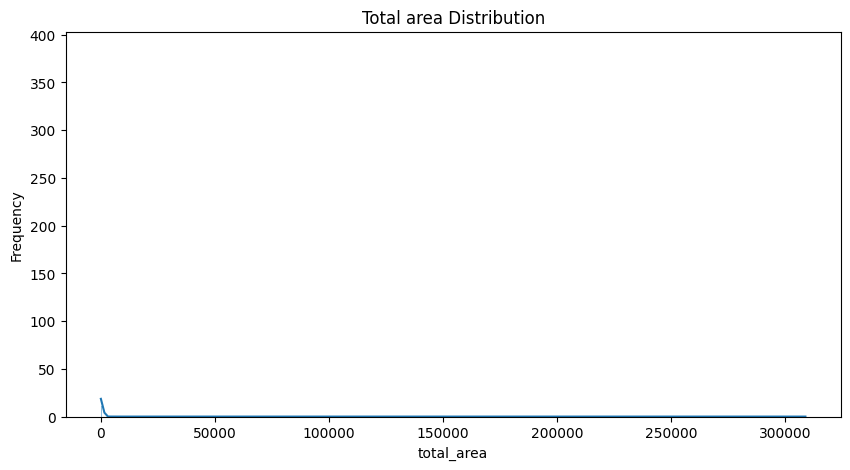

In [87]:
plot_distribution(df_clean['total_area'],'Total area Distribution','total_area')

In [88]:
df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\2492172101.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)


#### address column

In [89]:
df_missing=df_clean[df_clean['address'].isnull()]
df_full=df_clean[df_clean['address'].notna()]
print(len(df_missing))

164


In [90]:
# Initialize the geocoder with rate limiting
geolocator = Nominatim(user_agent="tunisia_property_analysis")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)
# Function to extract location info from coordinates
def get_location_info(lat, lon):
    try:
        location = geocode((lat, lon), language='fr')
        if location and location.raw.get('address'):
            address = location.raw['address']
            municipality = address.get('municipality') or address.get('city') or address.get('town') or address.get('village') or address.get('suburb')
            return municipality
        return None
    except Exception as e:
        time.sleep(2)
        return None
# Create a copy of df_missing
df_filled = df_missing.copy()
# Process in batches
batch_size = 10
total = len(df_missing)
municipalities = []

for i in range(0, total, batch_size):
    batch = df_missing.iloc[i:min(i + batch_size, total)]
    for _, row in batch.iterrows():
        municipality= get_location_info(row['latitude'], row['longitude'])
        municipalities.append(municipality)
    time.sleep(1)
df_filled['address'] = municipalities

In [91]:
df_clean = pd.concat([df_full, df_filled])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5055 entries, 0 to 5054
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             5011 non-null   float64
 1   address           4976 non-null   object 
 2   total_area        5055 non-null   float64
 3   rooms             5055 non-null   float64
 4   bathrooms         5055 non-null   float64
 5   terrace           5055 non-null   float64
 6   furnished         5055 non-null   float64
 7   air_conditioning  5055 non-null   float64
 8   heating           5055 non-null   float64
 9   security          5055 non-null   float64
 10  floor             5055 non-null   float64
 11  latitude          4985 non-null   float64
 12  longitude         4985 non-null   float64
 13  bedrooms          5055 non-null   float64
 14  garage            5055 non-null   float64
 15  garden            5055 non-null   float64
 16  pool              5055 non-null   float64
dtype

In [92]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False).head(5)

address      1.562809
longitude    1.384768
latitude     1.384768
price        0.870425
security     0.000000
dtype: float64

In [93]:
df_clean=df_clean.dropna(subset=['address','price','latitude','longitude'])

In [94]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False).head(5)

price       0.0
security    0.0
garden      0.0
garage      0.0
bedrooms    0.0
dtype: float64

### c- Handling outliers

#### Price column

we can't jsut remove outliers the normal way because some plecas have high price values like Marsa ,gammarth and some places have low prices so it is not logic to drop outliers without introducing some categorical place difference

In [95]:
print(df_clean['price'].min())
print(df_clean['price'].max())

0.0
520000000.0


In [96]:
print(df_clean.shape)
df_clean=df_clean[ (df_clean['price']>30000) & (df_clean['price']<9999999) ]
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

(4975, 17)
(4924, 17)
40000.0
8500000.0


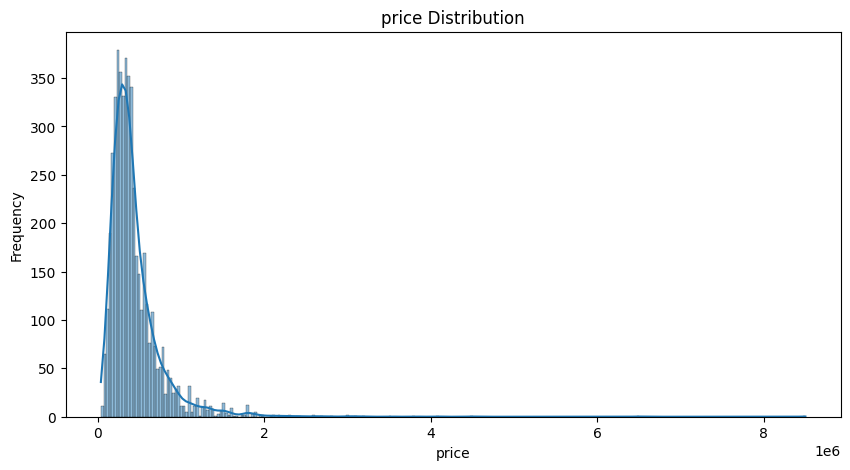

In [97]:
plot_distribution(df_clean['price'],'price Distribution','price')

In [98]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [99]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())


24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [100]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())


270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [101]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [102]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_municipality_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["municipality"],
                                             scorer=fuzz.partial_ratio)
    # Only return the municipality name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
df_clean["municipality"] = df_clean["address"].apply(get_municipality_if_good_match)

In [103]:
df_missing_municipality=df_clean[df_clean['municipality'].isna()]
df_full_municipality=df_clean[df_clean['municipality'].notna()]

In [104]:
# Function to get municipality from latitude and longitude
def get_municipality_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True,language="fr")
        address = location.raw['address']
        
        for field in ['municipality','city', 'town', 'village', 'suburb']:
            if field in address:
                return address[field]
        
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

for idx, row in df_missing_municipality.iterrows():
    municipality = get_municipality_from_coords(row['latitude'], row['longitude'])
    if municipality:
        df_missing_municipality.at[idx, 'municipality'] = municipality
    else:
        df_missing_municipality.at[idx, 'municipality'] = df_missing_municipality.at[idx,'address']
    time.sleep(1)  # Sleep to respect API rate limits

Error: 'NoneType' object has no attribute 'raw'
Error: 'NoneType' object has no attribute 'raw'
Error: 'NoneType' object has no attribute 'raw'


In [105]:
df_clean=pd.concat([df_missing_municipality,df_full_municipality])

In [106]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


we fill governorate based on the municipality , exemple : Manar => Ariana

In [107]:
# a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [108]:
missing_governorate=df_clean[df_clean['governorate'].isnull()]
not_missing_governorate=df_clean[df_clean['governorate'].notna()]
print(len(missing_governorate))
print(len(not_missing_governorate))


48
4876


In [109]:
def get_governorate_from_municipality(municipality_name):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        # Search for the municipality name in Tunisia
        location = geolocator.geocode(f"{municipality_name}, Tunisia", exactly_one=True, language="fr")
        if location:
            address_details = geolocator.reverse((location.latitude, location.longitude), language="fr").raw['address']
            for field in ['state', 'county', 'region', 'province']:
                if field in address_details:
                    return address_details[field]
        return None
    except Exception as e:
        return None
def get_governorate_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True, language="fr")
        address = location.raw['address']
        
        for field in ['state', 'county', 'region', 'province']:
            if field in address:
                return address[field]
        return None
    except Exception as e:
        return None
# Apply the function to rows with missing governorate but known municipality
for idx, row in missing_governorate.iterrows():
    if pd.notna(row['municipality']):
        # First try using municipality name
        governorate = get_governorate_from_municipality(row['municipality'])
        # If that fails and we have coordinates, try using them
        if not governorate:
            governorate = get_governorate_from_coords(row['latitude'], row['longitude'])   
        if governorate:
            missing_governorate.at[idx, 'governorate'] = governorate
            
        time.sleep(1)  # Sleep to respect API rate limits

In [110]:
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Gouvernorat Sousse' 'Gouvernorat Tunis' 'Gouvernorat Ariana'
 'Gouvernorat Nabeul' 'Pamplemousses' 'Corse' 'Gouvernorat Monastir']


In [111]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_governorate_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["governorate"],
                                             scorer=fuzz.partial_ratio)
    # Only return the governorate name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\2345721556.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)


In [112]:
missing_governorate = missing_governorate.dropna(subset=['governorate'])
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Sousse' 'Tunis' 'Ariana' 'Nabeul' 'Monastir']


In [113]:
print(df_clean.shape)
df_clean=pd.concat([missing_governorate,not_missing_governorate])
df_clean=df_clean.reset_index(drop=True)
print(df_clean.shape)

(4924, 19)
(4922, 19)


In [ ]:
"""
This part is responsible for removing price outliers based on the prices arround property area
prices are different from place to place
-Initally we iniate outliers_mask a pandas series with false values , later we change outliers index
to have a True value
-In the end we filter our original dataset with non outliers
"""
print("Original dataframe size:", len(df))
outliers_mask = pd.Series(False, index=df_clean.index)
# Only process municipalities with enough data points
min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
municipality_counts = df_clean['municipality'].value_counts()
valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

for municipality in valid_municipalities:
    # Get prices for this municipality
    municipality_prices = df_clean[df_clean['municipality'] == municipality]['price']
    
    # Calculate Q1, Q3 and IQR
    Q1 = municipality_prices.quantile(0.25)
    Q3 = municipality_prices.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers (typically 1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers for this municipality and getting it is index
    municipality_outliers = df_clean[
        (df_clean['municipality'] == municipality) & 
        ((df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound))
    ].index
    # Add to our overall outliers mask ,exemple outliers_mask.loc[42] = True
    outliers_mask.loc[municipality_outliers] = True    
# For municipalities with too few properties, we use global statistics
"""
-Let's say we have municipalities: "Ariana" (20 properties), "Marsa" (3 properties), "Carthage" (2 properties)
- municipality_counts < min_properties identifies municipalities with fewer than 5 properties: "Marsa" and "Carthage"
- .index gets their names: ["Marsa", "Carthage"]
- .isin() creates a boolean mask where True means the property is in a small municipality
- If property #100 is in "Marsa", then small_municipalities[100] will be True
"""
small_municipalities = df_clean['municipality'].isin(
    municipality_counts[municipality_counts < min_properties].index
)
if small_municipalities.sum() > 0:
    # Calculate global IQR
    all_prices = df_clean['price']
    global_Q1 = all_prices.quantile(0.25)
    global_Q3 = all_prices.quantile(0.75)
    global_IQR = global_Q3 - global_Q1
    
    global_lower = global_Q1 - 1.5 * global_IQR
    global_upper = global_Q3 + 1.5 * global_IQR
    # Identify outliers in small municipalities
    small_muni_outliers = df_clean[
        small_municipalities & 
        ((df_clean['price'] < global_lower) | (df_clean['price'] > global_upper))
    ].index
    # Add to our overall outliers mask
    outliers_mask.loc[small_muni_outliers] = True
# Remove the outliers
df_clean_no_outliers = df_clean[~outliers_mask].copy()
total_outliers = outliers_mask.sum()
print(f"Dataframe size after removing outliers: {len(df_clean_no_outliers)}")
# Replace the original dataframe with the cleaned one
df_clean = df_clean_no_outliers

Original dataframe size: 5055
Dataframe size after removing outliers: 4653


In [115]:
def boxplot(df_func,col):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_func[col])
    plt.title(col+' Box Plot')
    plt.xlabel('Number of '+col)
    plt.show()

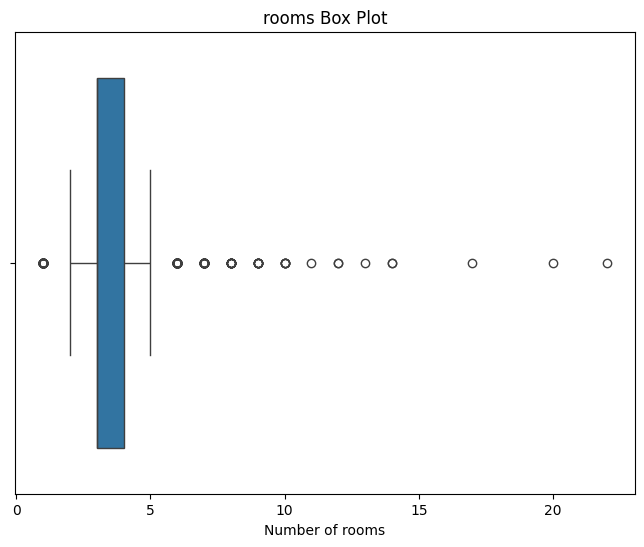

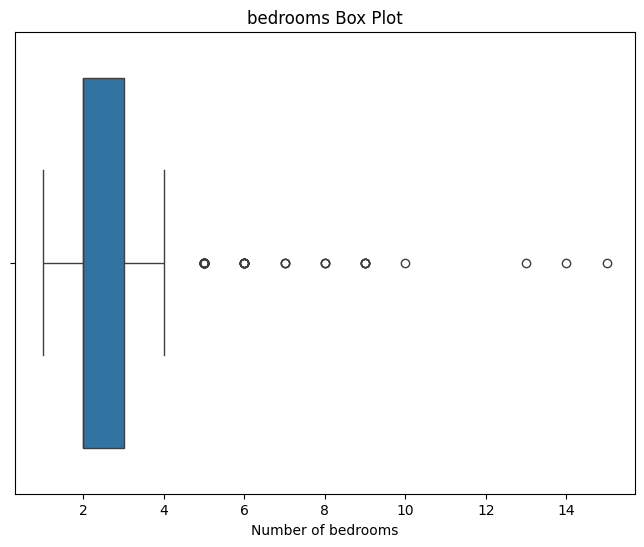

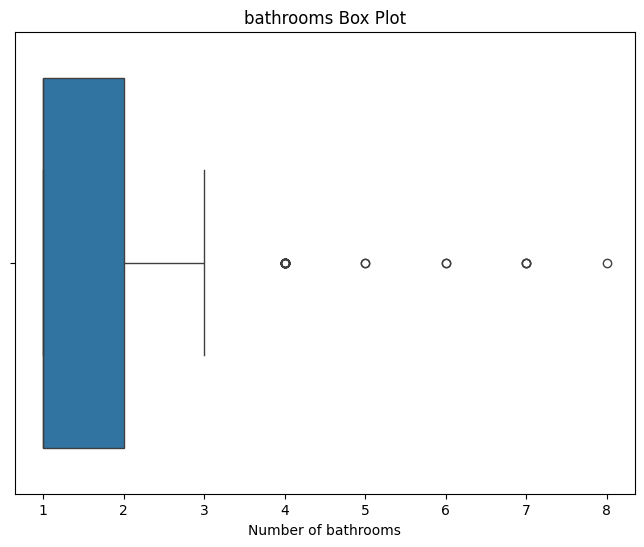

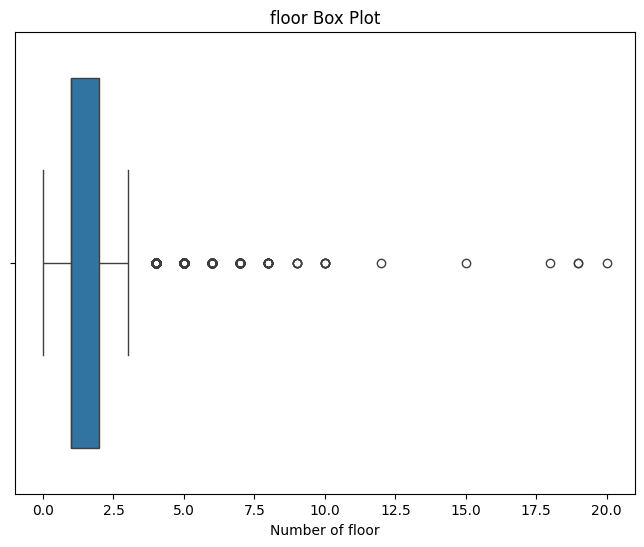

In [116]:
boxplot(df_clean,'rooms') 
boxplot(df_clean,'bedrooms')
boxplot(df_clean,'bathrooms')
boxplot(df_clean,'floor')

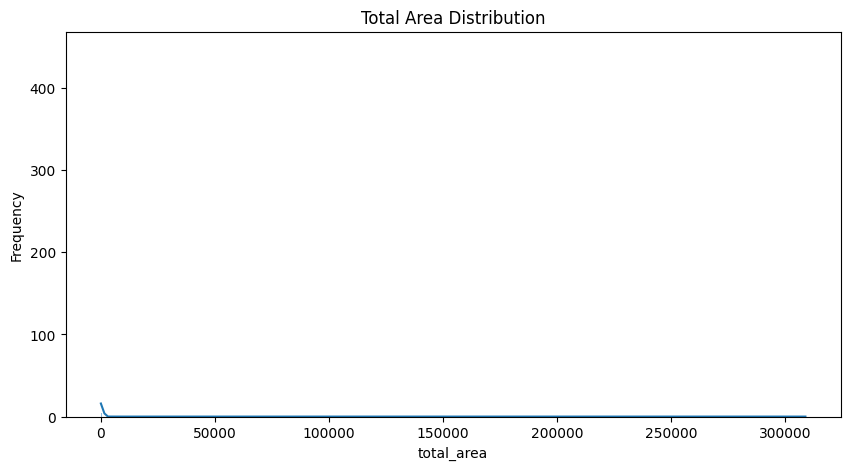

In [117]:

plot_distribution(df_clean['total_area'],'Total Area Distribution','total_area')


In [118]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [119]:

print(df_clean.shape)
for col in ['bedrooms','rooms','bathrooms','floor']:
    df_clean=remove_outliers_zscore(df_clean,col)
    print(df_clean.shape)


(4653, 19)
(4594, 19)
(4547, 19)
(4533, 19)
(4455, 19)


In [120]:

print("before removing outliers:",df_clean.shape)
def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
df_clean = remove_outliers_iqr(df_clean, 'total_area')
print("after removing outliers:",df_clean.shape)

before removing outliers: (4455, 19)
after removing outliers: (4309, 19)


In [121]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'floor',
       'latitude', 'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'municipality', 'governorate'],
      dtype='object')

## 3-Data visualization

<Axes: xlabel='price', ylabel='total_area'>

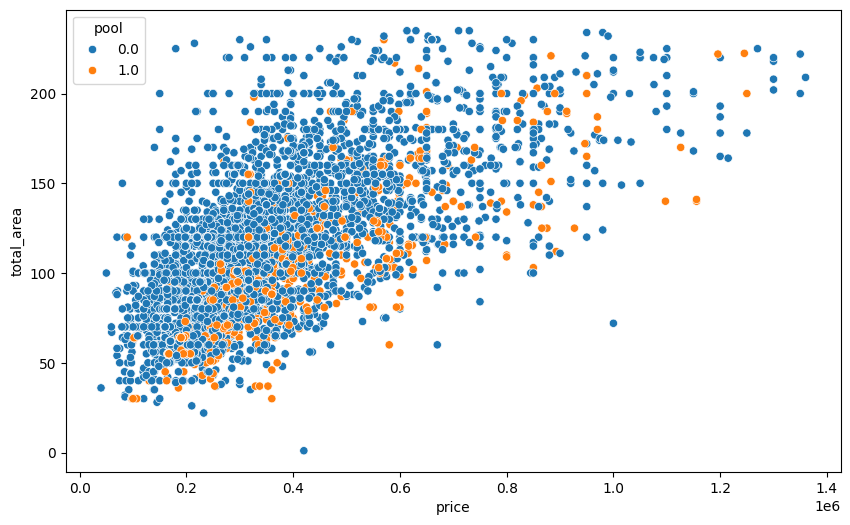

In [122]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['price'], y=df_clean['total_area'],hue=df_clean['pool'])

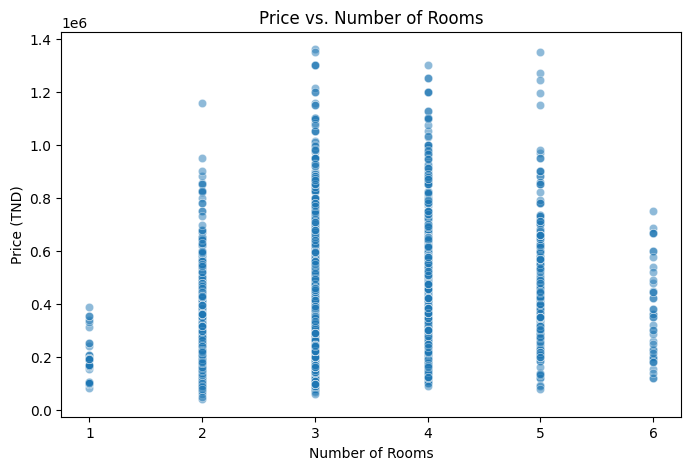

In [123]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rooms', y='price', data=df_clean, alpha=0.5)
plt.title('Price vs. Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price (TND)')
plt.show()

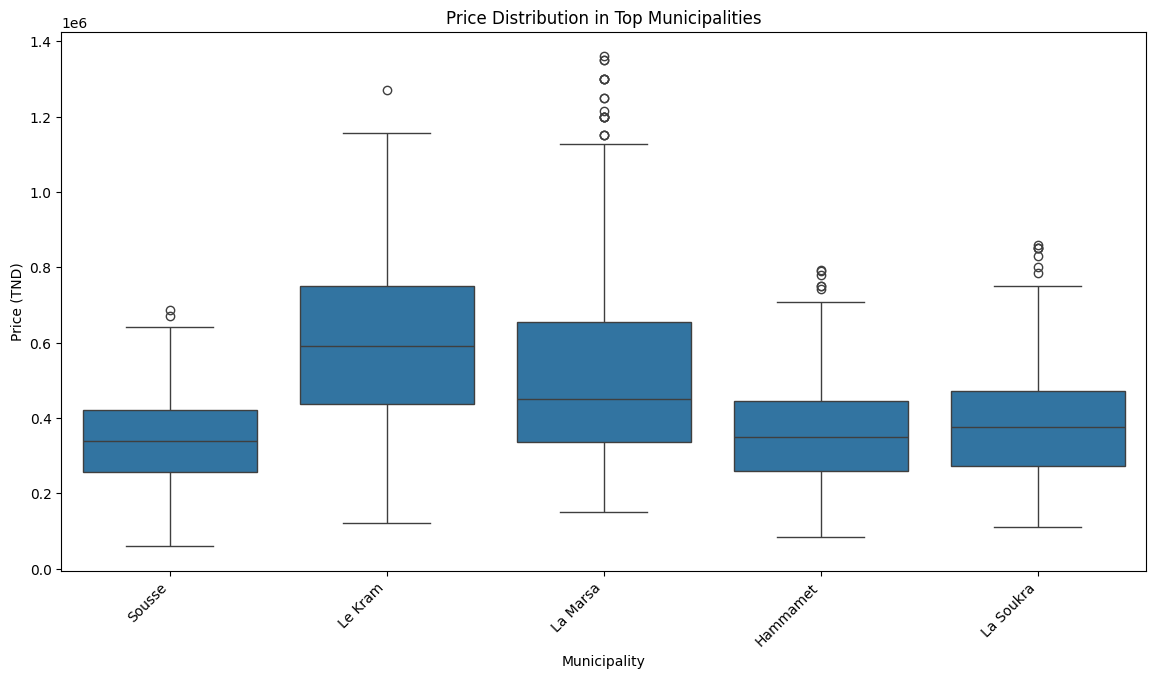

In [124]:
top_municipalities = df_clean.groupby('municipality')['price'].count().sort_values(ascending=False)
top_municipalities = top_municipalities[top_municipalities > 20].index[:5]
plt.figure(figsize=(14, 7))
sns.boxplot(x='municipality', y='price', 
            data=df_clean[df_clean['municipality'].isin(top_municipalities)])
plt.title('Price Distribution in Top Municipalities')
plt.xlabel('Municipality')
plt.ylabel('Price (TND)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [125]:
def count_figure(col):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df_clean, x=col, palette='deep')
    plt.title('Distribution of Apartments by '+col)
    plt.ylabel('Number of Apartments')
    plt.tight_layout()
    plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


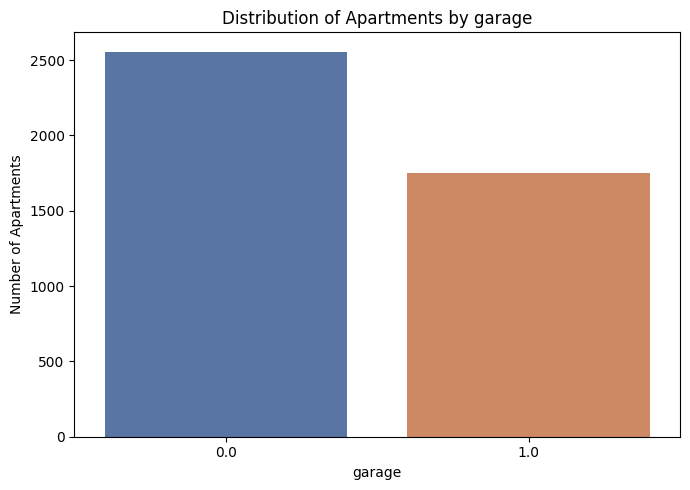

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


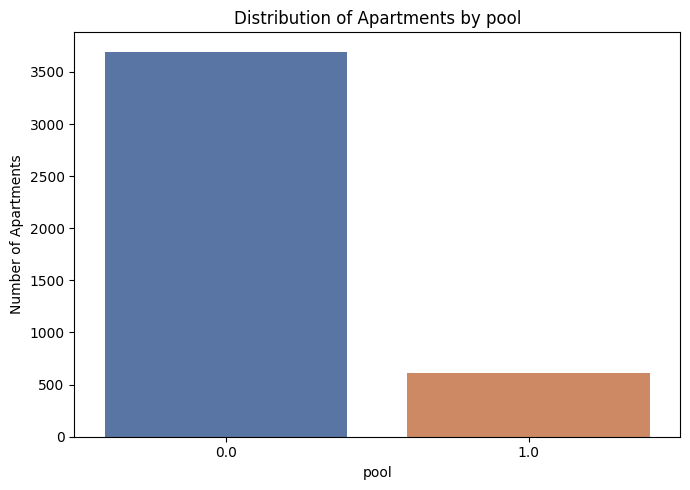

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


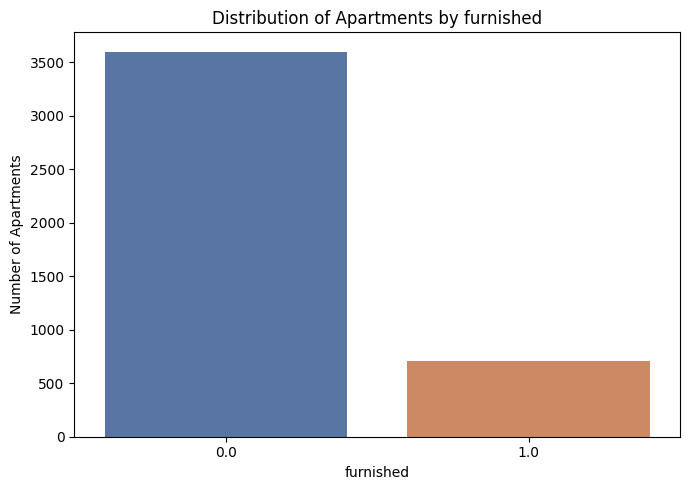

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


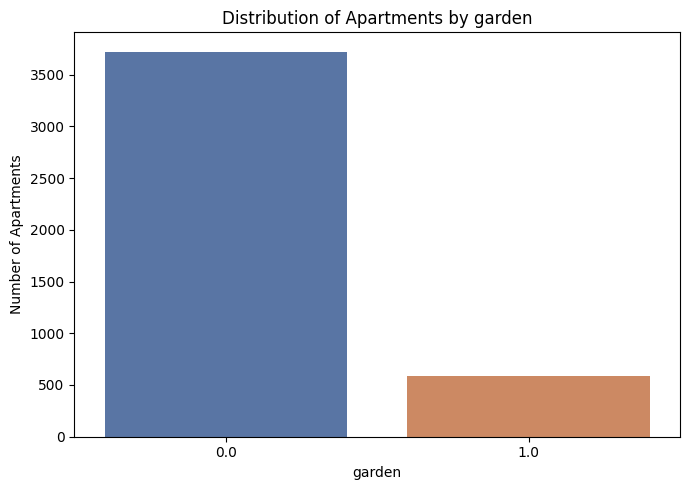

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


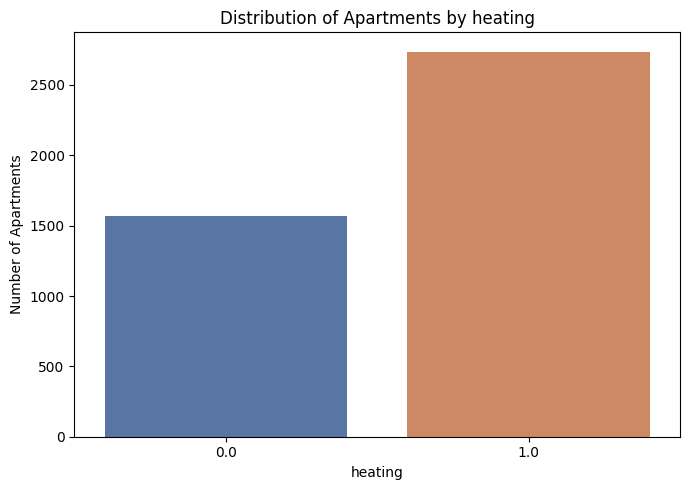

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


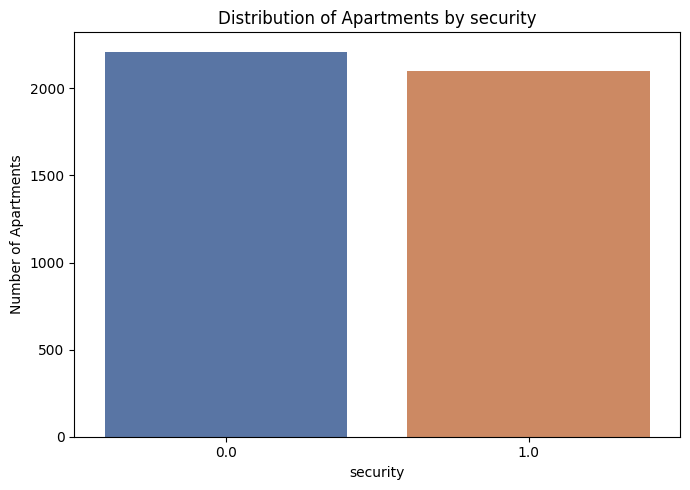

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


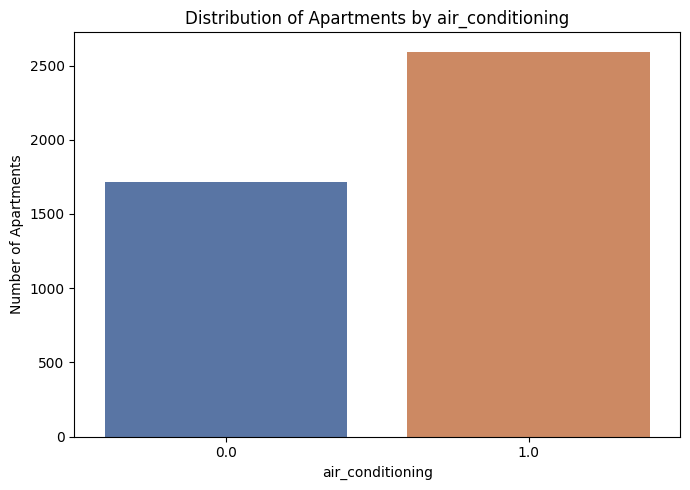

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


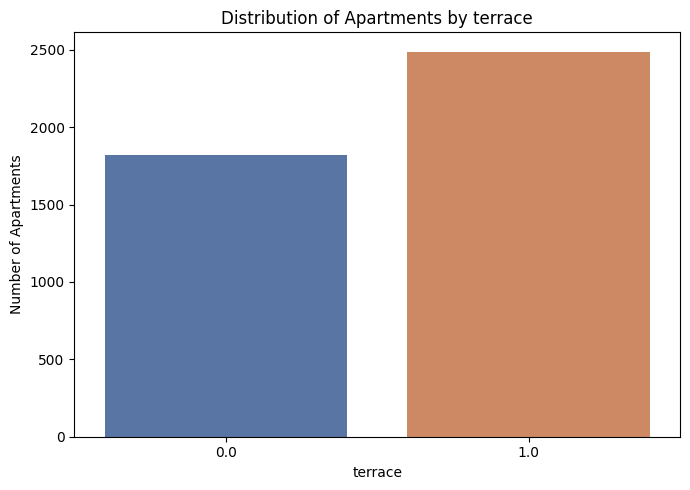

In [127]:
for col in ['garage','pool','furnished','garden','heating','security','air_conditioning','terrace']:
    count_figure(col)

## 4-Feature engineering and selection

In [128]:
df_clean.groupby('municipality')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
municipality,,,,,,,,
Ajim (Djerba),2.0,224500.000000,64346.717088,179000.00,201750.00,224500.00,247250.00,270000.00
Akouda,88.0,340466.226818,125880.295189,120000.00,247500.00,323196.54,425000.00,593440.12
Alaâ,1.0,380790.800000,NaN,380790.80,380790.80,380790.80,380790.80,380790.80
Ariana,330.0,364419.388242,141001.430111,110000.00,250000.00,360000.00,450000.00,730000.00
Barraket Essahel,2.0,227500.000000,130814.754520,135000.00,181250.00,227500.00,273750.00,320000.00
...,...,...,...,...,...,...,...,...
Tunis,150.0,257273.638400,126319.327060,70000.00,170000.00,245000.00,300000.00,781770.00
Téboulba,2.0,115000.000000,14142.135624,105000.00,110000.00,115000.00,120000.00,125000.00
Zaghouan,1.0,520000.000000,NaN,520000.00,520000.00,520000.00,520000.00,520000.00


In [129]:
# Calculate average price per municipality
municipality_avg_price = df_clean.groupby('municipality')['price'].mean().reset_index()
municipality_avg_price.columns = ['municipality', 'municipality_avg_price']
# Calculate average price per governorate
governorate_avg_price = df_clean.groupby('governorate')['price'].mean().reset_index()
governorate_avg_price.columns = ['governorate', 'governorate_avg_price']
df_clean = pd.merge(df_clean, municipality_avg_price, on='municipality', how='left')
df_clean = pd.merge(df_clean, governorate_avg_price, on='governorate', how='left')
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,...,latitude,longitude,bedrooms,garage,garden,pool,municipality,governorate,municipality_avg_price,governorate_avg_price
0,384000.0,Khezama Est,84.0,3.0,1.0,1.0,0.0,1.0,1.0,1.0,...,37.928879,11.320584,2.0,1.0,0.0,0.0,Khezama Est,Sousse,418000.0,334534.902487
1,340000.0,Cité El Menzah,148.0,4.0,1.0,1.0,0.0,0.0,0.0,1.0,...,32.960600,10.527630,3.0,1.0,1.0,0.0,Cité El Menzah,Tunis,340000.0,491843.886738
2,390000.0,Khezama Est,111.0,3.0,1.0,0.0,0.0,1.0,1.0,1.0,...,37.928879,11.320584,2.0,1.0,0.0,0.0,Khezama Est,Sousse,418000.0,334534.902487
3,320000.0,Mutuelle Ville à El Menzah,120.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,...,36.845235,10.164723,3.0,0.0,0.0,0.0,El Menzah 6,Ariana,320000.0,368962.047853
4,480000.0,Khezama Est,105.0,3.0,1.0,1.0,0.0,1.0,1.0,1.0,...,37.928879,11.320584,2.0,1.0,0.0,0.0,Khezama Est,Sousse,418000.0,334534.902487


In [130]:
def generate_quality(col):
    """
     Create municipality quality feature based on average prices
     Group by municipality and calculate statistics
    """
    stats = df_clean.groupby(col).agg({
        'price': ['mean', 'median', 'count']
    }).reset_index()
    # Flatten the multi-index columns
    stats.columns = [col, 'avg_price', 'median_price', 'property_count']
    # Separate reliable and unreliable
    min_samples = 3  # Minimum number of properties to consider reliable
    reliable = stats[stats['property_count'] >= min_samples]
    unreliable = stats[stats['property_count'] < min_samples]
    # Create quality tiers for reliable 
    if len(reliable) > 0:
        # Calculate price thresholds from reliable data
        low_threshold = reliable['avg_price'].quantile(0.33)
        high_threshold = reliable['avg_price'].quantile(0.67)
        # Create quality tiers using calculated thresholds
        reliable['price_tier'] = pd.cut(
            reliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['affordable_housing_area','mid_price_housing_area', 'premium_housing_area']
        )
        reliable['confidence'] = 'high'
    if len(unreliable) > 0:
        # Apply the same thresholds to unreliable municipalities
        unreliable['price_tier'] = pd.cut(
            unreliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['affordable_housing_area','mid_price_housing_area', 'premium_housing_area']
        )
        unreliable['confidence'] = 'low'
        
    # Combine all municipalities
    all_municipalities = pd.concat([reliable, unreliable]) 
    # Create mapping dictionaries
    quality_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['price_tier']
    ))
        
    confidence_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['confidence']
    ))
    return quality_map,confidence_map


In [131]:
# Apply the mappings to create new features
municipality_quality_map_mun,municipality_confidence_map_mun=generate_quality('municipality')
df_clean['municipality_quality'] = df_clean['municipality'].map(municipality_quality_map_mun)
df_clean['municipality_quality_confidence'] = df_clean['municipality'].map(municipality_confidence_map_mun)

municipality_quality_map_gov,municipality_confidence_map_gov=generate_quality('governorate')
df_clean['governorate_quality'] = df_clean['governorate'].map(municipality_quality_map_gov)
df_clean['governorate_quality_confidence'] = df_clean['governorate'].map(municipality_confidence_map_gov)

C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3675813930.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['price_tier'] = pd.cut(
C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3675813930.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['confidence'] = 'high'
C:\Users\MSI\AppData\Local\Temp\ipykernel_2228\3675813930.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [132]:
df_clean[['municipality','governorate','municipality_avg_price','governorate_avg_price',
            'municipality_quality','municipality_quality_confidence','governorate_quality',
            'governorate_quality_confidence']].head()

,municipality,governorate,municipality_avg_price,governorate_avg_price,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,Khezama Est,Sousse,418000.0,334534.902487,premium_housing_area,high,premium_housing_area,high
1,Cité El Menzah,Tunis,340000.0,491843.886738,mid_price_housing_area,low,premium_housing_area,high
2,Khezama Est,Sousse,418000.0,334534.902487,premium_housing_area,high,premium_housing_area,high
3,El Menzah 6,Ariana,320000.0,368962.047853,mid_price_housing_area,low,premium_housing_area,high
4,Khezama Est,Sousse,418000.0,334534.902487,premium_housing_area,high,premium_housing_area,high


In [133]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4309 entries, 0 to 4308
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            4309 non-null   float64
 1   address                          4309 non-null   object 
 2   total_area                       4309 non-null   float64
 3   rooms                            4309 non-null   float64
 4   bathrooms                        4309 non-null   float64
 5   terrace                          4309 non-null   float64
 6   furnished                        4309 non-null   float64
 7   air_conditioning                 4309 non-null   float64
 8   heating                          4309 non-null   float64
 9   security                         4309 non-null   float64
 10  floor                            4309 non-null   float64
 11  latitude                         4309 non-null   float64
 12  longitude           

### Encoding

In [134]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'floor',
       'latitude', 'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'municipality', 'governorate', 'municipality_avg_price',
       'governorate_avg_price', 'municipality_quality',
       'municipality_quality_confidence', 'governorate_quality',
       'governorate_quality_confidence'],
      dtype='object')

In [135]:
"""
mdf = df_clean.groupby('municipality').agg({
    'governorate': 'first',
    'municipality_avg_price': 'mean',
    'governorate_avg_price': 'mean',
    'municipality_quality': 'first',
    'municipality_quality_confidence': 'first',
    'governorate_quality': 'first',
    'governorate_quality_confidence': 'first'
})
mdf.to_csv('municipality_governorate_description.csv')
mdf.head()
"""


"\nmdf = df_clean.groupby('municipality').agg({\n    'governorate': 'first',\n    'municipality_avg_price': 'mean',\n    'governorate_avg_price': 'mean',\n    'municipality_quality': 'first',\n    'municipality_quality_confidence': 'first',\n    'governorate_quality': 'first',\n    'governorate_quality_confidence': 'first'\n})\nmdf.to_csv('municipality_governorate_description.csv')\nmdf.head()\n"

In [136]:
# List of categorical columns to convert
categorical_columns = [  'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence']
    # Create dummy variables and drop original columns
df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=False)

In [137]:
df_clean=df_clean.drop(columns=['municipality','governorate','address'],axis=1)

In [138]:
df_clean.columns

Index(['price', 'total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'floor', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'municipality_avg_price', 'governorate_avg_price',
       'municipality_quality_affordable_housing_area',
       'municipality_quality_mid_price_housing_area',
       'municipality_quality_premium_housing_area',
       'municipality_quality_confidence_high',
       'municipality_quality_confidence_low',
       'governorate_quality_affordable_housing_area',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

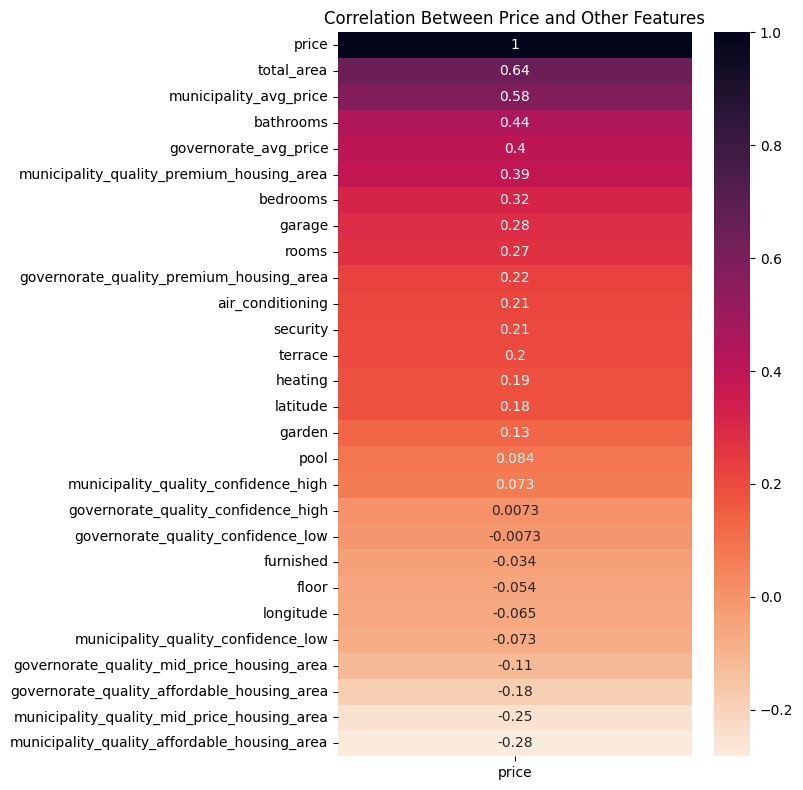

In [139]:
plt.figure(figsize=(8,8))
# Correlation matrix for price only
sns.heatmap(df_clean.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False), 
            annot=True, cmap='rocket_r', cbar=True)

plt.title("Correlation Between Price and Other Features")
plt.tight_layout()
plt.show()


In [140]:
#df_clean.to_csv('clean_apartment_data.csv',index=False)

In [141]:
#df_clean=pd.read_csv('synthatic_data_maison_acheter.csv')
#df_clean=df_clean.dropna()

## Modeling

In [142]:
df_clean.columns

Index(['price', 'total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'floor', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'municipality_avg_price', 'governorate_avg_price',
       'municipality_quality_affordable_housing_area',
       'municipality_quality_mid_price_housing_area',
       'municipality_quality_premium_housing_area',
       'municipality_quality_confidence_high',
       'municipality_quality_confidence_low',
       'governorate_quality_affordable_housing_area',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

In [168]:
X=df_clean.drop(columns=['price'],axis=1)
y=df_clean['price']
print(X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(4309, 27)


In [144]:
X.iloc[0,:]

total_area                                               84.0
rooms                                                     3.0
bathrooms                                                 1.0
terrace                                                   1.0
furnished                                                 0.0
air_conditioning                                          1.0
heating                                                   1.0
security                                                  1.0
floor                                                     1.0
latitude                                            37.928879
longitude                                           11.320584
bedrooms                                                  2.0
garage                                                    1.0
garden                                                    0.0
pool                                                      0.0
municipality_avg_price                               418000.0
governor

In [163]:
X.columns

Index(['total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'floor', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool',
       'governorate_avg_price', 'governorate_quality_affordable_housing_area',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

In [146]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    
    print("Model: ",model_name)
    print(f"Training R²: {train_r2:.3f}, Test R²: {test_r2:.3f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.3f}")

In [147]:
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

#### Linear Regression

In [169]:
from sklearn.preprocessing import StandardScaler
lr=LinearRegression()
# Add StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,"Linear Regression")

Model:  Linear Regression
Training R²: 0.659, Test R²: 0.685
Training MAE: 79734.48, Test MAE: 83804.59
R² Difference (Overfitting): -0.025


### Decision Tree Regressor

Starting hyperparameter search for Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'min_samples_split': 25, 'min_samples_leaf': 6, 'max_features': 0.5, 'max_depth': 15}
Model:  Decision Tree
Training R²: 0.743, Test R²: 0.619
Training MAE: 68865.84, Test MAE: 91217.04
R² Difference (Overfitting): 0.124

Cross-validation R² scores: [0.59582201 0.6470977  0.58830691 0.59924285 0.54926457]
Mean CV R² score: 0.5959
Standard deviation of CV R² scores: 0.0312


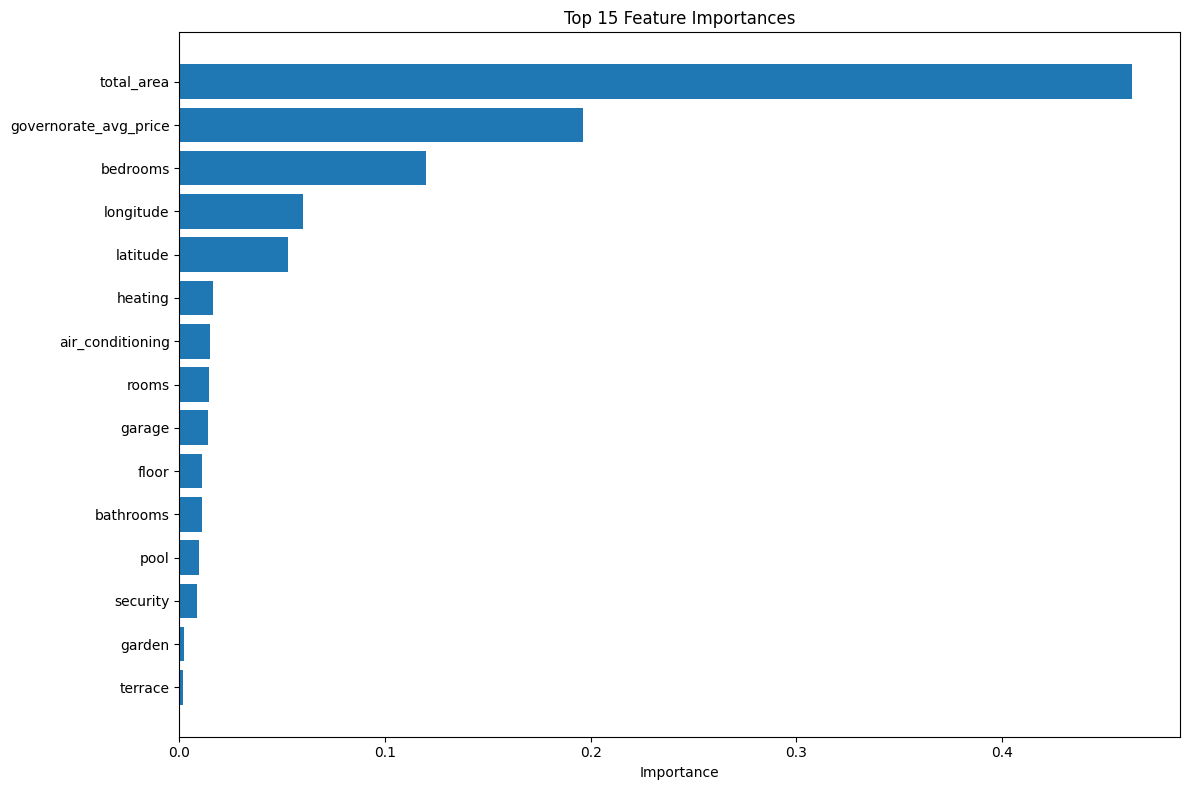

In [165]:
# Define the parameter distribution for Decision Tree
param_dist = {
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of the tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]  # Number of features to consider when looking for the best split
}
# Create a base Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search for Decision Tree...")
dt_random.fit(X_train, y_train)
print("Hyperparameter search completed!")
# Get the best parameters and score
print(f"Best parameters: {dt_random.best_params_}")
# Create a model with the best parameters
best_dt = DecisionTreeRegressor(**dt_random.best_params_, random_state=42)
evaluate_model(best_dt, X_train, X_test, y_train, y_test, "Decision Tree")
cross_val_evaluate(best_dt)

### Random forest

Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': True}
Model:  Random forest
Training R²: 0.873, Test R²: 0.727
Training MAE: 46417.85, Test MAE: 74565.48
R² Difference (Overfitting): 0.146

Cross-validation R² scores: [0.70376976 0.72078383 0.70095865 0.70762736 0.68907594]
Mean CV R² score: 0.7044
Standard deviation of CV R² scores: 0.0103


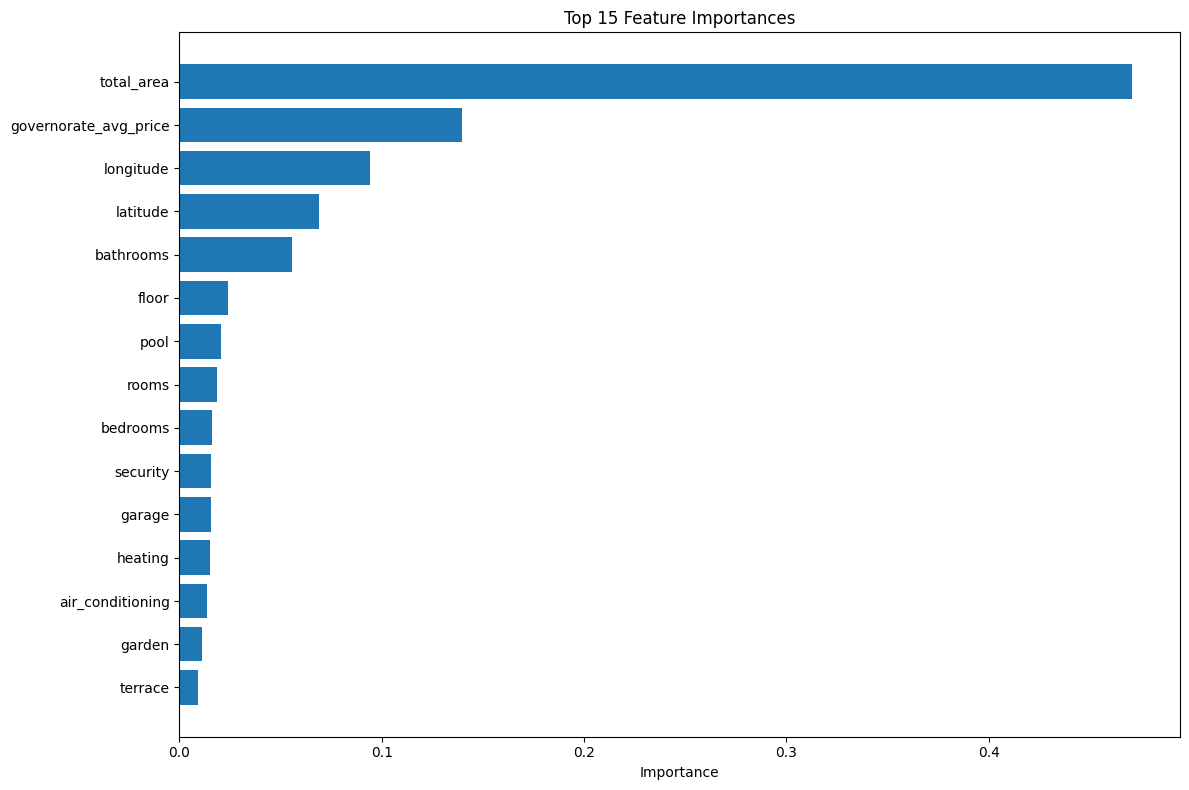

In [166]:
# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees in the forest
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of each tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # Number of features to consider when looking for the best split
    'bootstrap': [True],  # Whether bootstrap samples are used when building trees
    'oob_score': [True],  # Whether to use out-of-bag samples to estimate the generalization error
    'max_samples': [0.7, 0.8, 0.9, None]  # Fraction of samples to draw from X to train each base estimator
}

# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test, "Random forest")
cross_val_evaluate(best_rf)

### Voting Regressor

In [167]:
voting_ensemble = VotingRegressor(
    estimators=[
        ('rf', best_rf),
        ('lr', lr),
    ],
    weights=[1,1]  # Equal weights for all models
)
evaluate_model(voting_ensemble, X_train, X_test, y_train, y_test,"Voting ensemble")
cv_scores = cross_val_score(voting_ensemble, X_train, y_train, cv=5, scoring='r2')
print(cv_scores)

Model:  Voting ensemble
Training R²: 0.772, Test R²: 0.712
Training MAE: 65357.15, Test MAE: 79911.00
R² Difference (Overfitting): 0.060
[0.69179872 0.68695071 0.67459792 0.67183617 0.66117111]


In [ ]:
"""
import pickle
with open('apartment_buying_half.pkl','wb') as file:
    pickle.dump(voting_ensemble,file)
"""


"\nimport pickle\nwith open('apartment_buying_full.pkl','wb') as file:\n    pickle.dump(voting_ensemble,file)\n"